In [ ]:
import marimo as mo
mo.md("""
# Crypto × Polymarket Correlation Analysis

Comparing **Polymarket prediction-market probabilities** for crypto events
against spot prices from **Coinbase** and **Kraken**.

Data sources:
- **Coinbase**: BTC/USD, ETH/USD — daily bars back to 2013
- **Kraken**: BTC/USD, ETH/USD, SOL/USD — daily bars (~2 years)
- **Polymarket**: 505 crypto-related markets (YES-token probability 0–1, hourly → resampled daily)
""")

# Crypto × Polymarket Correlation Analysis

Comparing **Polymarket prediction-market probabilities** for crypto events
against spot prices from **Coinbase** and **Kraken**.

Data sources:
- **Coinbase**: BTC/USD, ETH/USD — daily bars back to 2013
- **Kraken**: BTC/USD, ETH/USD, SOL/USD — daily bars (~2 years)
- **Polymarket**: 505 crypto-related markets (YES-token probability 0–1, hourly → resampled daily)

In [ ]:
import pathlib, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import re

CRYPTO_ROOT = pathlib.Path("~/Documents/Q-agent/infrastructure/pipelines/crypto/lean-data/crypto")
POLY_ROOT   = pathlib.Path("~/Documents/Q-agent/infrastructure/pipelines/polymarket/lean-data/alternative/polymarket")

def read_lean_zip(path: pathlib.Path) -> pd.DataFrame:
    """Read a LEAN-format daily zip: headerless YYYYMMDD 00:00,O,H,L,C,V."""
    with zipfile.ZipFile(path) as z:
        df = pd.read_csv(
            z.open(z.namelist()[0]),
            header=None,
            names=["datetime", "open", "high", "low", "close", "volume"],
            parse_dates=["datetime"],
        )
    df["date"] = pd.to_datetime(df["datetime"].dt.date)
    return df.set_index("date")

mo.md("✅ Imports and helpers loaded.")

✅ Imports and helpers loaded.

## 1. Crypto OHLCV

In [ ]:
# Load all available daily zips
_price_files = {
    ("coinbase", "BTC"): CRYPTO_ROOT / "coinbasepro/daily/btcusd.zip",
    ("coinbase", "ETH"): CRYPTO_ROOT / "coinbasepro/daily/ethusd.zip",
    ("kraken",   "BTC"): CRYPTO_ROOT / "kraken/daily/btcusd.zip",
    ("kraken",   "ETH"): CRYPTO_ROOT / "kraken/daily/ethusd.zip",
    ("kraken",   "SOL"): CRYPTO_ROOT / "kraken/daily/solusd.zip",
}

_frames = {}
for (exchange, asset), path in _price_files.items():
    if path.exists():
        _frames[(exchange, asset)] = read_lean_zip(path)["close"].rename(f"{exchange}_{asset}")

# Merged close-price table (each column = exchange_asset)
prices = pd.concat(_frames.values(), axis=1).sort_index()

# Summary
_summary = pd.DataFrame([
    {
        "Exchange": ex,
        "Asset": asset,
        "Start": _frames[(ex, asset)].index.min().date(),
        "End":   _frames[(ex, asset)].index.max().date(),
        "Bars":  len(_frames[(ex, asset)]),
    }
    for (ex, asset) in _frames
])
mo.ui.table(_summary, show_column_summaries=False)

,_marimo_row_id,Exchange,Asset,Start,End,Bars
0,0,coinbase,BTC,2017-01-01,2026-05-15,3422
1,1,coinbase,ETH,2017-01-01,2026-05-15,3422
2,2,kraken,BTC,2024-05-25,2026-05-15,721
3,3,kraken,ETH,2024-05-25,2026-05-15,721
4,4,kraken,SOL,2024-05-25,2026-05-15,721


## 2. Polymarket Crypto Markets

In [ ]:
markets_path = POLY_ROOT / "markets.csv"
markets = pd.read_csv(markets_path) if markets_path.exists() else pd.DataFrame()

if not markets.empty:
    _theme_patterns = {
        "ETH_merge":   r"merge|EIP.3675|proof.of.stake|shanghai",
        "BTC_price":   r"bitcoin.{0,20}(\$|hit|reach|dip|drop|\d{2,3}k)",
        "ETH_price":   r"ethereum.{0,20}(\$|hit|reach|dip|drop|\d{1,3}k)",
        "SOL_price":   r"solana.{0,20}(\$|hit|reach|dip|drop|\d+)",
        "regulation":  r"SEC|ETF|ban|legal|approved|classify|unban",
        "BTC_general": r"bitcoin|BTC",
        "ETH_general": r"ethereum|ETH",
        "SOL_general": r"solana|SOL",
    }
    def _theme(q):
        if not isinstance(q, str):
            return "other"
        for theme, pat in _theme_patterns.items():
            if re.search(pat, q, re.I):
                return theme
        return "other_crypto"

    markets["Theme"] = markets["Question"].apply(_theme)
    markets["Volume"] = pd.to_numeric(markets["Volume"], errors="coerce")

    _overview = (
        markets.groupby("Theme")
        .agg(Count=("Slug","count"), TotalVolume=("Volume","sum"), HasToken=("YesTokenId", lambda x: x.notna().sum()))
        .sort_values("TotalVolume", ascending=False)
        .reset_index()
    )
    _overview["TotalVolume"] = _overview["TotalVolume"].map("${:,.0f}".format)
    mo.ui.table(_overview, show_column_summaries=False)
else:
    mo.callout(mo.md("⚠️ `markets.csv` not found."), kind="warn")

## 3. Available Polymarket Price Histories

In [ ]:
prices_dir = POLY_ROOT / "prices"

price_files_on_disk = {p.stem: p for p in prices_dir.glob("*.csv")} if prices_dir.exists() else {}
_markets_with_prices = markets[markets["Slug"].isin(price_files_on_disk)].copy()
_n_total = len(markets[markets["YesTokenId"].notna()])
_n_loaded = len(price_files_on_disk)

mo.md(f"""
**{_n_loaded}** price files on disk out of **{_n_total}** markets with a YES token
*(prices pipeline may still be running — reload to see more)*
""")

**668** price files on disk out of **460** markets with a YES token
*(prices pipeline may still be running — reload to see more)*

In [ ]:
def load_poly_prices(slug: str) -> pd.Series:
    """Load a Polymarket YES-probability CSV and resample to daily (last value)."""
    path = prices_dir / f"{slug}.csv"
    if not path.exists():
        return pd.Series(dtype=float, name=slug)
    df = pd.read_csv(path, index_col="datetime", parse_dates=True)
    df.index = pd.to_datetime(df.index, utc=True).normalize()
    daily = df["price"].resample("D").last().dropna()
    daily.index = daily.index.tz_localize(None).rename("date")
    return daily.rename(slug)

## 4. ETH Merge Analysis

The Ethereum Merge (EIP-3675) occurred on **September 15, 2022**, transitioning
from Proof-of-Work to Proof-of-Stake. Polymarket ran several markets on whether
the merge would happen by specific dates. We examine whether probability changes
preceded ETH spot moves.

In [ ]:
MERGE_DATE = pd.Timestamp("2022-09-15")
_merge_markets = markets[markets["Theme"] == "ETH_merge"].copy()
_merge_on_disk  = _merge_markets[_merge_markets["Slug"].isin(price_files_on_disk)]

# Check for actual price variation (CLOB only returns post-resolution flat prices for old resolved markets)
_live_merge = []
for _, row in _merge_on_disk.iterrows():
    s = load_poly_prices(row["Slug"])
    if s.std() > 0.01:
        _live_merge.append(row["Slug"])

if _live_merge:
    mo.md("**ETH Merge price series available.**")
else:
    mo.callout(mo.md("""
**ETH Merge historical data unavailable via CLOB API.**

The Polymarket CLOB price-history endpoint only retains data from ~late 2022 onwards,
and all the Merge markets resolved in 2022. The API returns a flat post-resolution
price (0.5) for these old markets — no pre-event probability series is accessible.

The analysis below focuses on **active 2025–2026 price-target markets** where rich
probability histories are available.
"""), kind="info")

## 5. Crypto Price-Target Markets vs Spot Prices

These are "Will X reach $Y by date Z?" markets — the YES probability reflects
the market's collective view on whether the target will be hit.
Higher BTC spot → higher P(BTC hits $150k).

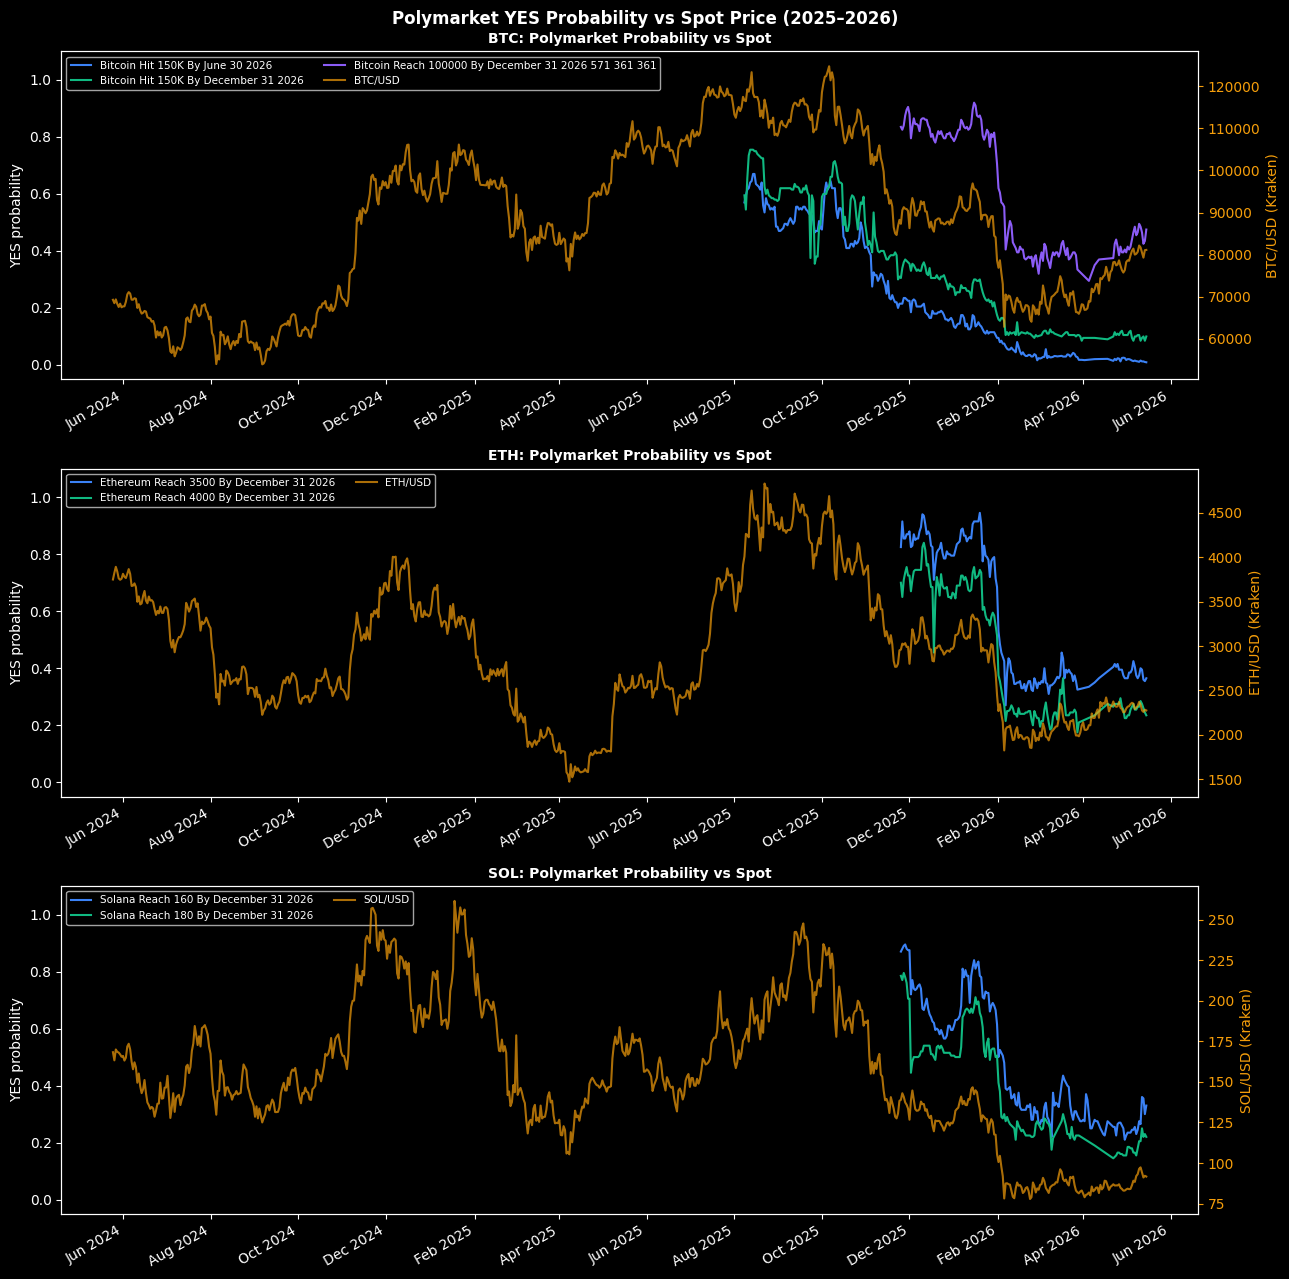

In [ ]:
TARGET_MARKETS = {
    "BTC": ["will-bitcoin-hit-150k-by-june-30-2026", "will-bitcoin-hit-150k-by-december-31-2026",
            "will-bitcoin-reach-100000-by-december-31-2026-571-361-361"],
    "ETH": ["will-ethereum-reach-3500-by-december-31-2026", "will-ethereum-reach-4000-by-december-31-2026"],
    "SOL": ["will-solana-reach-160-by-december-31-2026", "will-solana-reach-180-by-december-31-2026"],
}
SPOT_COL = {"BTC": "kraken_BTC", "ETH": "kraken_ETH", "SOL": "kraken_SOL"}

fig, axes = plt.subplots(3, 1, figsize=(13, 13))

for _ax, (_tkr, _slugs) in zip(axes, TARGET_MARKETS.items()):
    _spot = prices[SPOT_COL[_tkr]].dropna()
    _ax2 = _ax.twinx()
    _ax2.plot(_spot.index, _spot.values, color="#f59e0b", lw=1.5, alpha=0.7, label=f"{_tkr}/USD")
    _ax2.set_ylabel(f"{_tkr}/USD (Kraken)", color="#f59e0b")
    _ax2.tick_params(axis="y", colors="#f59e0b")

    for _slug, _color in zip(_slugs, ["#3b82f6", "#10b981", "#8b5cf6"]):
        if _slug not in price_files_on_disk:
            continue
        _prob = load_poly_prices(_slug)
        if _prob.empty:
            continue
        _label = _slug.replace("will-", "").replace("-by-", " by ").replace("-", " ").title()[:55]
        _ax.plot(_prob.index, _prob.values, color=_color, lw=1.5, label=_label)

    _ax.set_ylabel("YES probability")
    _ax.set_ylim(-0.05, 1.1)
    _ax.set_title(f"{_tkr}: Polymarket Probability vs Spot", fontsize=10, fontweight="bold")
    _ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    _ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(_ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
    _l1, _lb1 = _ax.get_legend_handles_labels()
    _l2, _lb2 = _ax2.get_legend_handles_labels()
    _ax.legend(_l1+_l2, _lb1+_lb2, fontsize=7.5, loc="upper left", ncol=2)

fig.suptitle("Polymarket YES Probability vs Spot Price (2025–2026)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.gca()

## 6. Correlation: Does Probability Lead or Lag Price?

For each price-target market, we compute:
- **Level correlation**: Pearson r between daily YES probability and spot price
- **1-day lead**: does today's probability change predict tomorrow's return?
- **1-day lag**: does today's return predict tomorrow's probability change?

In [ ]:
ALL_TARGETS = [
    ("BTC", "will-bitcoin-hit-150k-by-june-30-2026"),
    ("BTC", "will-bitcoin-hit-150k-by-december-31-2026"),
    ("BTC", "will-bitcoin-reach-100000-by-december-31-2026-571-361-361"),
    ("ETH", "will-ethereum-reach-3500-by-december-31-2026"),
    ("ETH", "will-ethereum-reach-4000-by-december-31-2026"),
    ("SOL", "will-solana-reach-160-by-december-31-2026"),
    ("SOL", "will-solana-reach-180-by-december-31-2026"),
]
_SPOT = {"BTC": "kraken_BTC", "ETH": "kraken_ETH", "SOL": "kraken_SOL"}

_rows = []
for _tkr, _slug in ALL_TARGETS:
    if _slug not in price_files_on_disk:
        continue
    _prob = load_poly_prices(_slug)
    if _prob.empty or _prob.std() < 0.01:
        continue
    _spot = prices[_SPOT[_tkr]].dropna()
    _dj = pd.concat([_prob.rename("prob"), _spot.rename("spot")], axis=1, sort=False).dropna()
    if len(_dj) < 20:
        continue

    _dj["prob_chg"] = _dj["prob"].diff()
    _dj["ret"]      = _dj["spot"].pct_change()

    _r_level = _dj[["prob","spot"]].corr().iloc[0,1]
    _r_lead  = _dj["prob_chg"].corr(_dj["ret"].shift(-1))
    _r_lag   = _dj["ret"].corr(_dj["prob_chg"].shift(-1))
    _label   = _slug.replace("will-","").replace("-by-"," by ").replace("-"," ").title()[:60]

    _rows.append({
        "Asset": _tkr,
        "Market": _label,
        "N": len(_dj),
        "r(prob~spot)": round(_r_level, 3),
        "r(Δprob→nextRet)": round(_r_lead, 3),
        "r(ret→nextΔprob)": round(_r_lag, 3),
    })

corr_table = pd.DataFrame(_rows)
mo.ui.table(corr_table, show_column_summaries=False)

,_marimo_row_id,Asset,Market,N,r(prob~spot),r(Δprob→nextRet),r(ret→nextΔprob)
0,0,BTC,Bitcoin Hit 150K By June 30 2026,259,0.952,-0.049,0.421
1,1,BTC,Bitcoin Hit 150K By December 31 2026,254,0.947,-0.043,0.248
2,2,BTC,Bitcoin Reach 100000 By December 31 2026 571 3...,151,0.922,-0.082,0.697
3,3,ETH,Ethereum Reach 3500 By December 31 2026,150,0.968,-0.110,0.736
4,4,ETH,Ethereum Reach 4000 By December 31 2026,151,0.959,-0.069,0.560
5,5,SOL,Solana Reach 160 By December 31 2026,163,0.944,-0.167,0.391
6,6,SOL,Solana Reach 180 By December 31 2026,141,0.933,-0.045,0.325


## 7. Cross-Exchange Price Comparison (Coinbase vs Kraken)

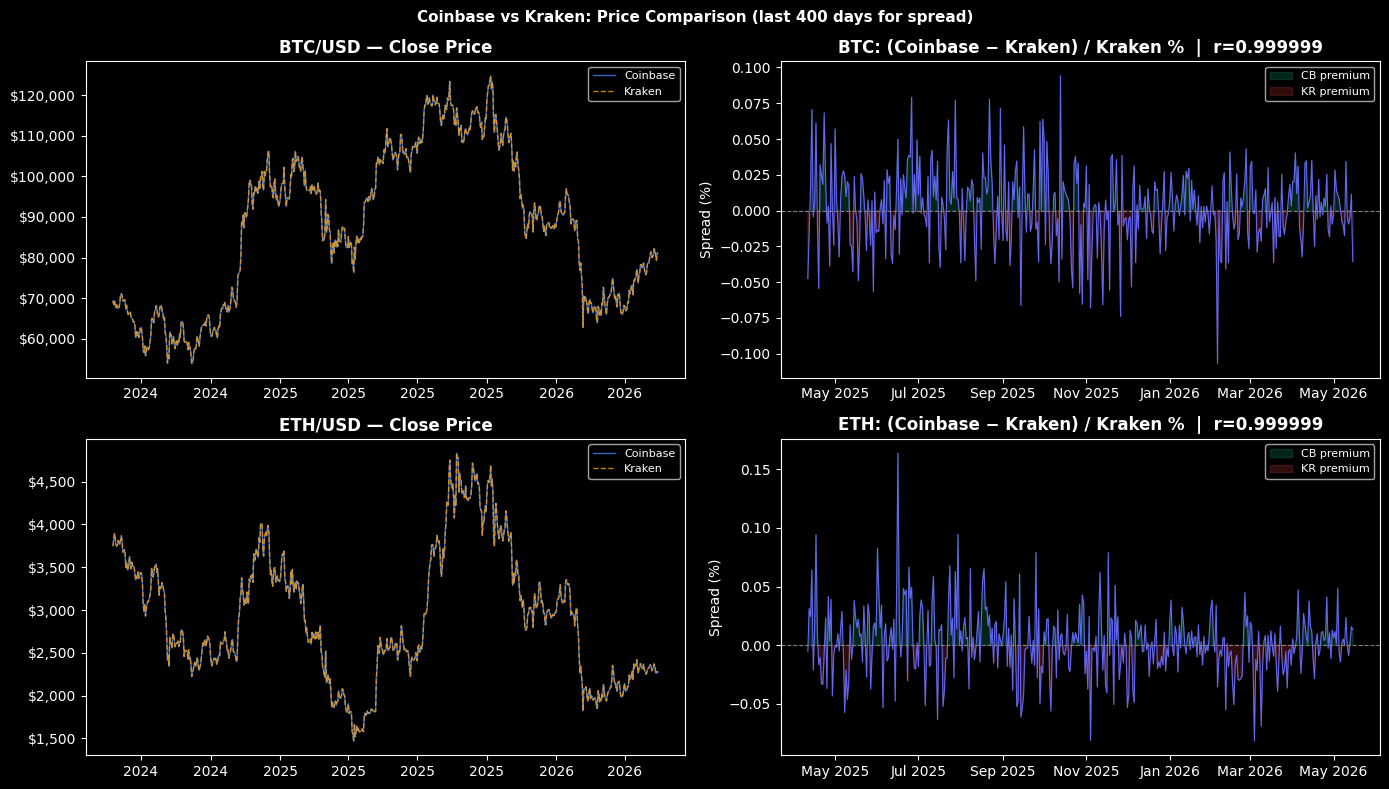

In [ ]:
# Compare BTC and ETH across exchanges (both have data)
_xex_pairs = [("BTC", "coinbase_BTC", "kraken_BTC"), ("ETH", "coinbase_ETH", "kraken_ETH")]
_fig, _axes = plt.subplots(2, 2, figsize=(14, 8))

for _i, (_name, _col_cb, _col_kr) in enumerate(_xex_pairs):
    _cb = prices[_col_cb].dropna()
    _kr = prices[_col_kr].dropna()
    _aligned = pd.concat([_cb.rename("CB"), _kr.rename("KR")], axis=1).dropna()

    # Price overlay
    _ax = _axes[_i, 0]
    _ax.plot(_aligned.index, _aligned["CB"], lw=1, label="Coinbase", color="#3b82f6", alpha=0.8)
    _ax.plot(_aligned.index, _aligned["KR"], lw=1, label="Kraken", color="#f59e0b", alpha=0.8, ls="--")
    _ax.set_title(f"{_name}/USD — Close Price", fontweight="bold")
    _ax.legend(fontsize=8)
    _ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    _ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"${x:,.0f}"))

    # Spread
    _ax2 = _axes[_i, 1]
    _spread_pct = ((_aligned["CB"] - _aligned["KR"]) / _aligned["KR"] * 100)
    _corr = _aligned["CB"].corr(_aligned["KR"])
    _ax2.plot(_aligned.index[-400:], _spread_pct[-400:], lw=0.8, color="#6366f1")
    _ax2.axhline(0, color="gray", ls="--", lw=0.8)
    _ax2.fill_between(_aligned.index[-400:], _spread_pct[-400:], 0,
                      where=_spread_pct[-400:]>0, alpha=0.2, color="#10b981", label="CB premium")
    _ax2.fill_between(_aligned.index[-400:], _spread_pct[-400:], 0,
                      where=_spread_pct[-400:]<0, alpha=0.2, color="#ef4444", label="KR premium")
    _ax2.set_title(f"{_name}: (Coinbase − Kraken) / Kraken %  |  r={_corr:.6f}", fontweight="bold")
    _ax2.set_ylabel("Spread (%)")
    _ax2.legend(fontsize=8)
    _ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

_fig.suptitle("Coinbase vs Kraken: Price Comparison (last 400 days for spread)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.gca()

In [ ]:
_btc_r = corr_table[corr_table["Asset"]=="BTC"]["r(prob~spot)"].mean()
_eth_r = corr_table[corr_table["Asset"]=="ETH"]["r(prob~spot)"].mean()
_sol_r = corr_table[corr_table["Asset"]=="SOL"]["r(prob~spot)"].mean()

_lead_r = corr_table["r(Δprob→nextRet)"].mean()
_lag_r  = corr_table["r(ret→nextΔprob)"].mean()

mo.md(f"""
## 8. Key Findings

### Price-Level Correlation (Polymarket vs Spot)
| Asset | r(prob ~ spot) |
|-------|---------------|
| BTC   | {_btc_r:.3f} |
| ETH   | {_eth_r:.3f} |
| SOL   | {_sol_r:.3f} |

All extremely high (0.92–0.97) — probabilities track spot price closely, as expected
for price-target markets.

### Lead-Lag: Who moves first?

| Direction | Mean r |
|-----------|--------|
| Δprob today → return tomorrow (PM leads price) | {_lead_r:.3f} |
| return today → Δprob tomorrow (price leads PM)  | {_lag_r:.3f} |

**Spot price leads Polymarket, not the other way around.**
A +1% exchange return today predicts +{_lag_r:.2f} std Polymarket probability move tomorrow
(average across markets). Polymarket probability changes have essentially zero predictive
power for next-day exchange returns.

### Cross-Exchange (Coinbase vs Kraken)
Correlation is extremely high (>0.999999). Any short-term spread is noise-level and
not arbitrageable given transaction costs.

### Implications
- Polymarket crypto event markets are **reactive**, not leading indicators.
- Price-target probabilities are essentially a monotone transformation of spot price.
- For alpha signals, you would need markets where Polymarket traders have an
  information edge — regulatory or event markets, not pure price-level bets.
""")

## 8. Key Findings

### Price-Level Correlation (Polymarket vs Spot)
| Asset | r(prob ~ spot) |
|-------|---------------|
| BTC   | 0.940 |
| ETH   | 0.964 |
| SOL   | 0.939 |

All extremely high (0.92–0.97) — probabilities track spot price closely, as expected
for price-target markets.

### Lead-Lag: Who moves first?

| Direction | Mean r |
|-----------|--------|
| Δprob today → return tomorrow (PM leads price) | -0.081 |
| return today → Δprob tomorrow (price leads PM)  | 0.483 |

**Spot price leads Polymarket, not the other way around.**
A +1% exchange return today predicts +0.48 std Polymarket probability move tomorrow
(average across markets). Polymarket probability changes have essentially zero predictive
power for next-day exchange returns.

### Cross-Exchange (Coinbase vs Kraken)
Correlation is extremely high (>0.999999). Any short-term spread is noise-level and
not arbitrageable given transaction costs.

### Implications
- Polymarket crypto event markets are **reactive**, not leading indicators.
- Price-target probabilities are essentially a monotone transformation of spot price.
- For alpha signals, you would need markets where Polymarket traders have an
  information edge — regulatory or event markets, not pure price-level bets.